Weight logit (z) probability result:
    10     -8.00      0.0003  Not Obese
    20     -6.00      0.0025  Not Obese
    30     -4.00      0.0180  Not Obese
    40     -2.00      0.1192  Not Obese
    60      2.00      0.8808  Obese


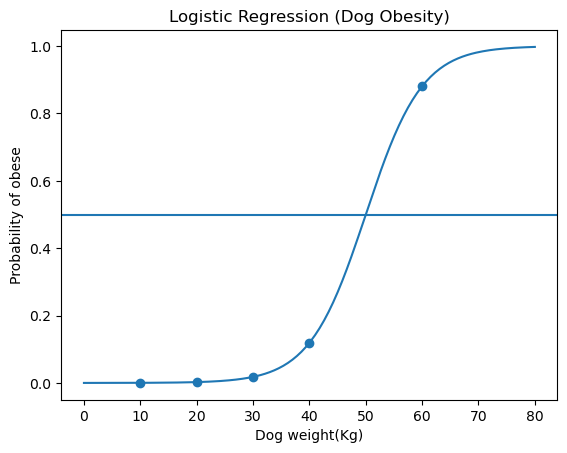

In [4]:
#Logistic Regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#given params
b0=-10
b1=0.2

#dog weights (out sample data)
weights=np.array([10,20,30,40,60])

#logit values
z=b0+b1*weights

#sigmoid fun
def sigmoid(z):
    return 1/(1+np.exp(-z))

#probabilities
probs=sigmoid(z)
print("Weight logit (z) probability result:")
for w,logit, p in zip (weights,z,probs):
    result="Obese" if p>=0.5 else "Not Obese"
    print(f"{w:6}  {logit:8.2f}  {p:10.4f}  {result}")
#classification
x_vals=np.linspace(0,80,200)
z_vals=b0+b1*x_vals
y_vals=sigmoid(z_vals)

#plot
plt.figure()
plt.plot(x_vals,y_vals)
plt.scatter(weights,probs)
#decision boundary line
plt.axhline(y=0.5)
plt.xlabel("Dog weight(Kg)")
plt.ylabel("Probability of obese")
plt.title("Logistic Regression (Dog Obesity)")
plt.show()

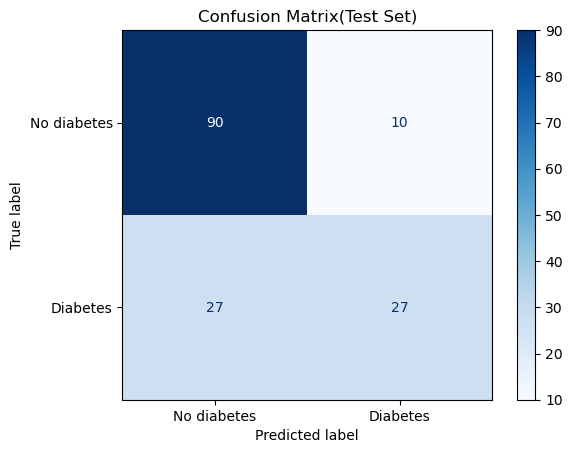

              precision    recall  f1-score   support

           0       0.77      0.90      0.83       100
           1       0.73      0.50      0.59        54

    accuracy                           0.76       154
   macro avg       0.75      0.70      0.71       154
weighted avg       0.76      0.76      0.75       154



In [5]:
# logistic regression on diabetes dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('diabetes.csv')
x = df.drop('Outcome',axis=1)
y = df['Outcome']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=101, stratify=y)

scaler = StandardScaler()
x_train['Insulin']=scaler.fit_transform(x_train[['Insulin']])
x_test['Insulin']=scaler.transform(x_test[['Insulin']])

model = LogisticRegression(max_iter=500)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=['No diabetes','Diabetes']).plot(cmap='Blues')
plt.title('Confusion Matrix(Test Set)')
plt.show()
print(classification_report(y_test, y_pred))